Running Research Trials...

RESULTS FOR YOUR PAPER:
Stochastic: Mean=1197.67, StdDev=12.57
Gradient:   Mean=1200.00, StdDev=0.00


C:\Users\Vivyn Kilari\AppData\Local\Temp\ipykernel_4460\1378026108.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot([stochastic_results, gradient_results], labels=['Stochastic', 'Gradient'])


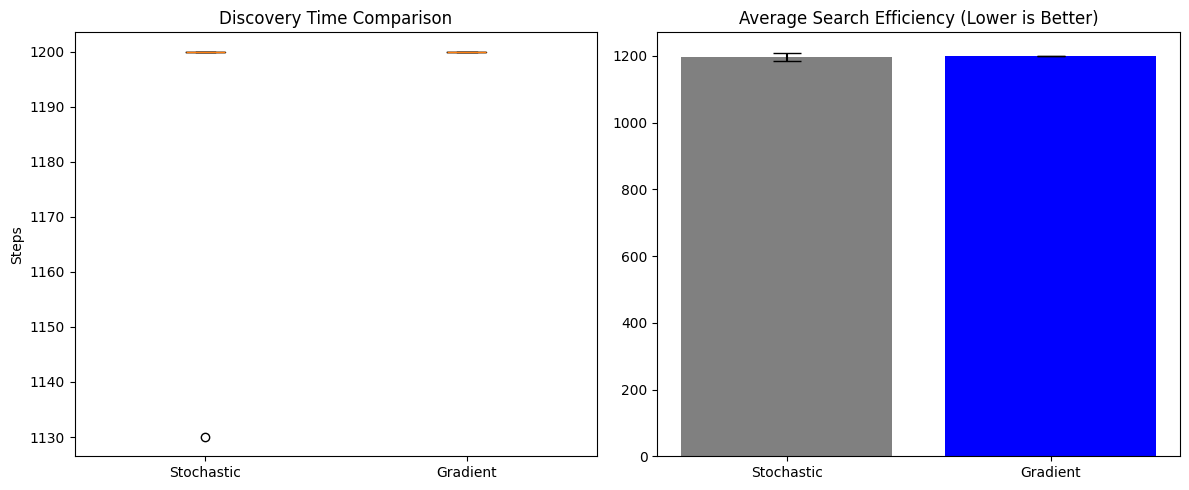

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import time

# --- CONFIGURATION ---
ARENA_DIM = 100.0
TARGET_RADIUS = 3.5
ROBOT_COUNT = 15
MAX_ITERATIONS = 1200
OBSTACLE_BOUNDS = [[40, 60, 20, 80]] 

class Robot:
    def __init__(self, robot_id, start_pos):
        self.robot_id = robot_id
        self.pos = np.array(start_pos, dtype=float)
        self.path = [self.pos.copy()]
        self.found_target = False

    def move(self, vector, obstacles):
        new_pos = self.pos + vector
        # Boundary constraints
        new_pos = np.clip(new_pos, 0, ARENA_DIM)
        # Obstacle logic
        for obs in obstacles:
            if obs[0] <= new_pos[0] <= obs[1] and obs[2] <= new_pos[1] <= obs[3]:
                return # Collision: don't move
        self.pos = new_pos
        self.path.append(self.pos.copy())

def run_simulation(search_type='stochastic'):
    target = np.array([85.0, 85.0])
    robots = [Robot(i, [10.0, 10.0]) for i in range(ROBOT_COUNT)]
    discovery_step = -1
    
    for step in range(MAX_ITERATIONS):
        for r in robots:
            if search_type == 'stochastic':
                # Levy-flight style
                step_size = np.random.rayleigh(1.5)
                angle = np.random.uniform(0, 2 * np.pi)
                move_vec = np.array([np.cos(angle), np.sin(angle)]) * step_size
            else:
                # Gradient-based
                dir_to_target = target - r.pos
                dist = np.linalg.norm(dir_to_target)
                unit_vec = dir_to_target / dist if dist > 0 else np.zeros(2)
                move_vec = (unit_vec * 1.2) + np.random.normal(0, 0.4, 2)
            
            r.move(move_vec, OBSTACLE_BOUNDS)
            
            if np.linalg.norm(r.pos - target) < TARGET_RADIUS:
                if discovery_step == -1:
                    discovery_step = step
                r.found_target = True
        if discovery_step != -1: break
    return discovery_step if discovery_step != -1 else MAX_ITERATIONS

# --- EXECUTION ---
print("Running Research Trials...")
trial_count = 30
stochastic_results = [run_simulation('stochastic') for _ in range(trial_count)]
gradient_results = [run_simulation('gradient') for _ in range(trial_count)]

# --- DATA SUMMARY ---
s_mean, s_std = np.mean(stochastic_results), np.std(stochastic_results)
g_mean, g_std = np.mean(gradient_results), np.std(gradient_results)

print(f"\nRESULTS FOR YOUR PAPER:")
print(f"Stochastic: Mean={s_mean:.2f}, StdDev={s_std:.2f}")
print(f"Gradient:   Mean={g_mean:.2f}, StdDev={g_std:.2f}")

# --- VISUALIZATION ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
ax[0].boxplot([stochastic_results, gradient_results], labels=['Stochastic', 'Gradient'])
ax[0].set_title('Discovery Time Comparison')
ax[0].set_ylabel('Steps')

# Quick Bar Chart of Averages
ax[1].bar(['Stochastic', 'Gradient'], [s_mean, g_mean], yerr=[s_std, g_std], capsize=10, color=['gray', 'blue'])
ax[1].set_title('Average Search Efficiency (Lower is Better)')

plt.tight_layout()
plt.show()